# Examples run on Class (March 25, 2026)

[0.59683333 0.30304041 0.89987182 0.40185118]


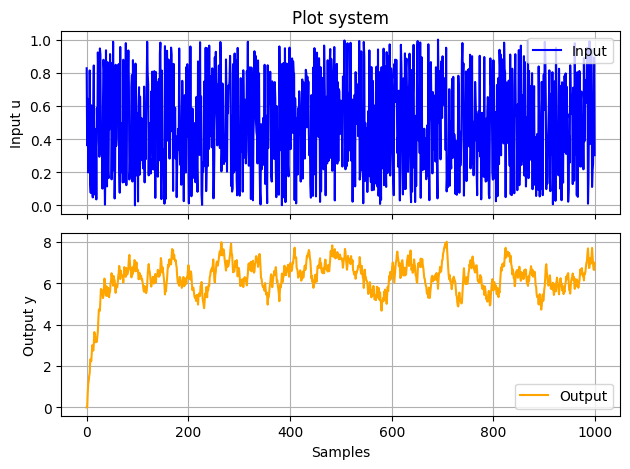

In [1]:
import matplotlib.pyplot as plt
import numpy as np

N = 1000

a1 = 0.6
a2 = 0.3
b1 = 0.9
b2 = 0.4

# Create a random number generator
# rng = np.random.default_rng()

# Generate N random floats between 0.0 (inclusive) and 1.0 (exclusive)
# u = rng.random(size=N)
u = np.random.uniform(size=N)
e = np.random.normal(0, 0.01, size=N)
y = np.zeros(N)

for k in range(2, N):
    y[k] = a1 * y[k - 1] + a2 * y[k - 2] + b1 * u[k - 1] + b2 * u[k - 2] + e[k]


# Método dos mínimos quadrados
# theta_est = (psi_trans * psi)ˆ-1*psi_trans*y

psi = np.zeros((N - 2, 4))
for k in range(2, N):
    psi[k - 2, 0] = y[k - 1]
    psi[k - 2, 1] = y[k - 2]
    psi[k - 2, 2] = u[k - 1]
    psi[k - 2, 3] = u[k - 2]

psi_trans = psi.T
theta_est = np.linalg.inv(psi_trans @ psi) @ psi_trans @ y[2:]

print(theta_est)


# plt.plot(y)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

ax1.plot(u, label="Input", color="blue", linestyle="-")
ax1.set_ylabel("Input u")
ax1.set_title("Plot system")
ax1.legend()
ax1.grid(True)

ax2.plot(y, label="Output", color="orange", linestyle="-")
ax2.set_ylabel("Output y")
ax2.set_xlabel("Samples")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# print(len(u))
# print(len(y))
